<a href="https://colab.research.google.com/github/sankajithdjinasena/MachineLearningProjects/blob/main/Medical_Cost_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import kagglehub
import pandas as pd
import os

In [5]:
path=kagglehub.dataset_download("mirichoi0218/insurance")
print("Folder path:", path)

Using Colab cache for faster access to the 'insurance' dataset.
Folder path: /kaggle/input/insurance


In [3]:
csv_file_path = os.path.join(path, "insurance.csv")
print("Exact csv path:", csv_file_path)

Exact csv path: /root/.cache/kagglehub/datasets/mirichoi0218/insurance/versions/1/insurance.csv


In [6]:
df = pd.read_csv(csv_file_path)
print("First 5 records:", df.head())

First 5 records:    age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.shape

(1337, 7)

In [21]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

BMI vs Charges: Split by Region and Smoke Status

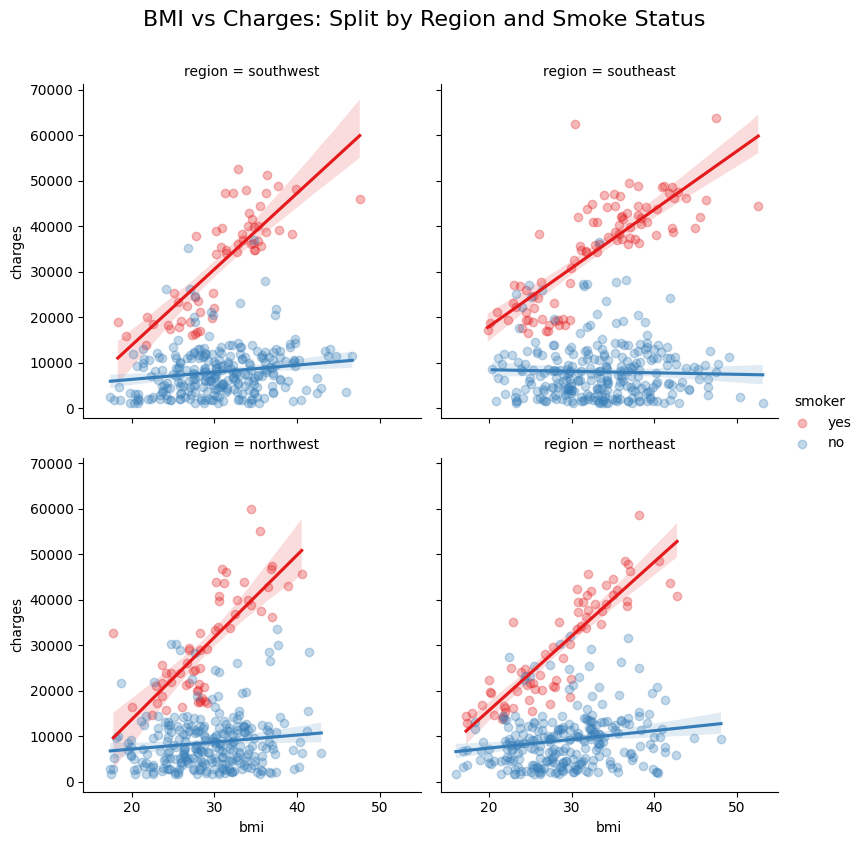

In [14]:
sns.lmplot(x="bmi", y="charges",hue="smoker",col="region",
           col_wrap=2, height=4, palette="Set1", data=df,
           scatter_kws={"alpha":0.3})

plt.suptitle("BMI vs Charges: Split by Region and Smoke Status", y=1.05, fontsize=16)
plt.show()

Age vs Charges: Split by Sex and Smoke Status

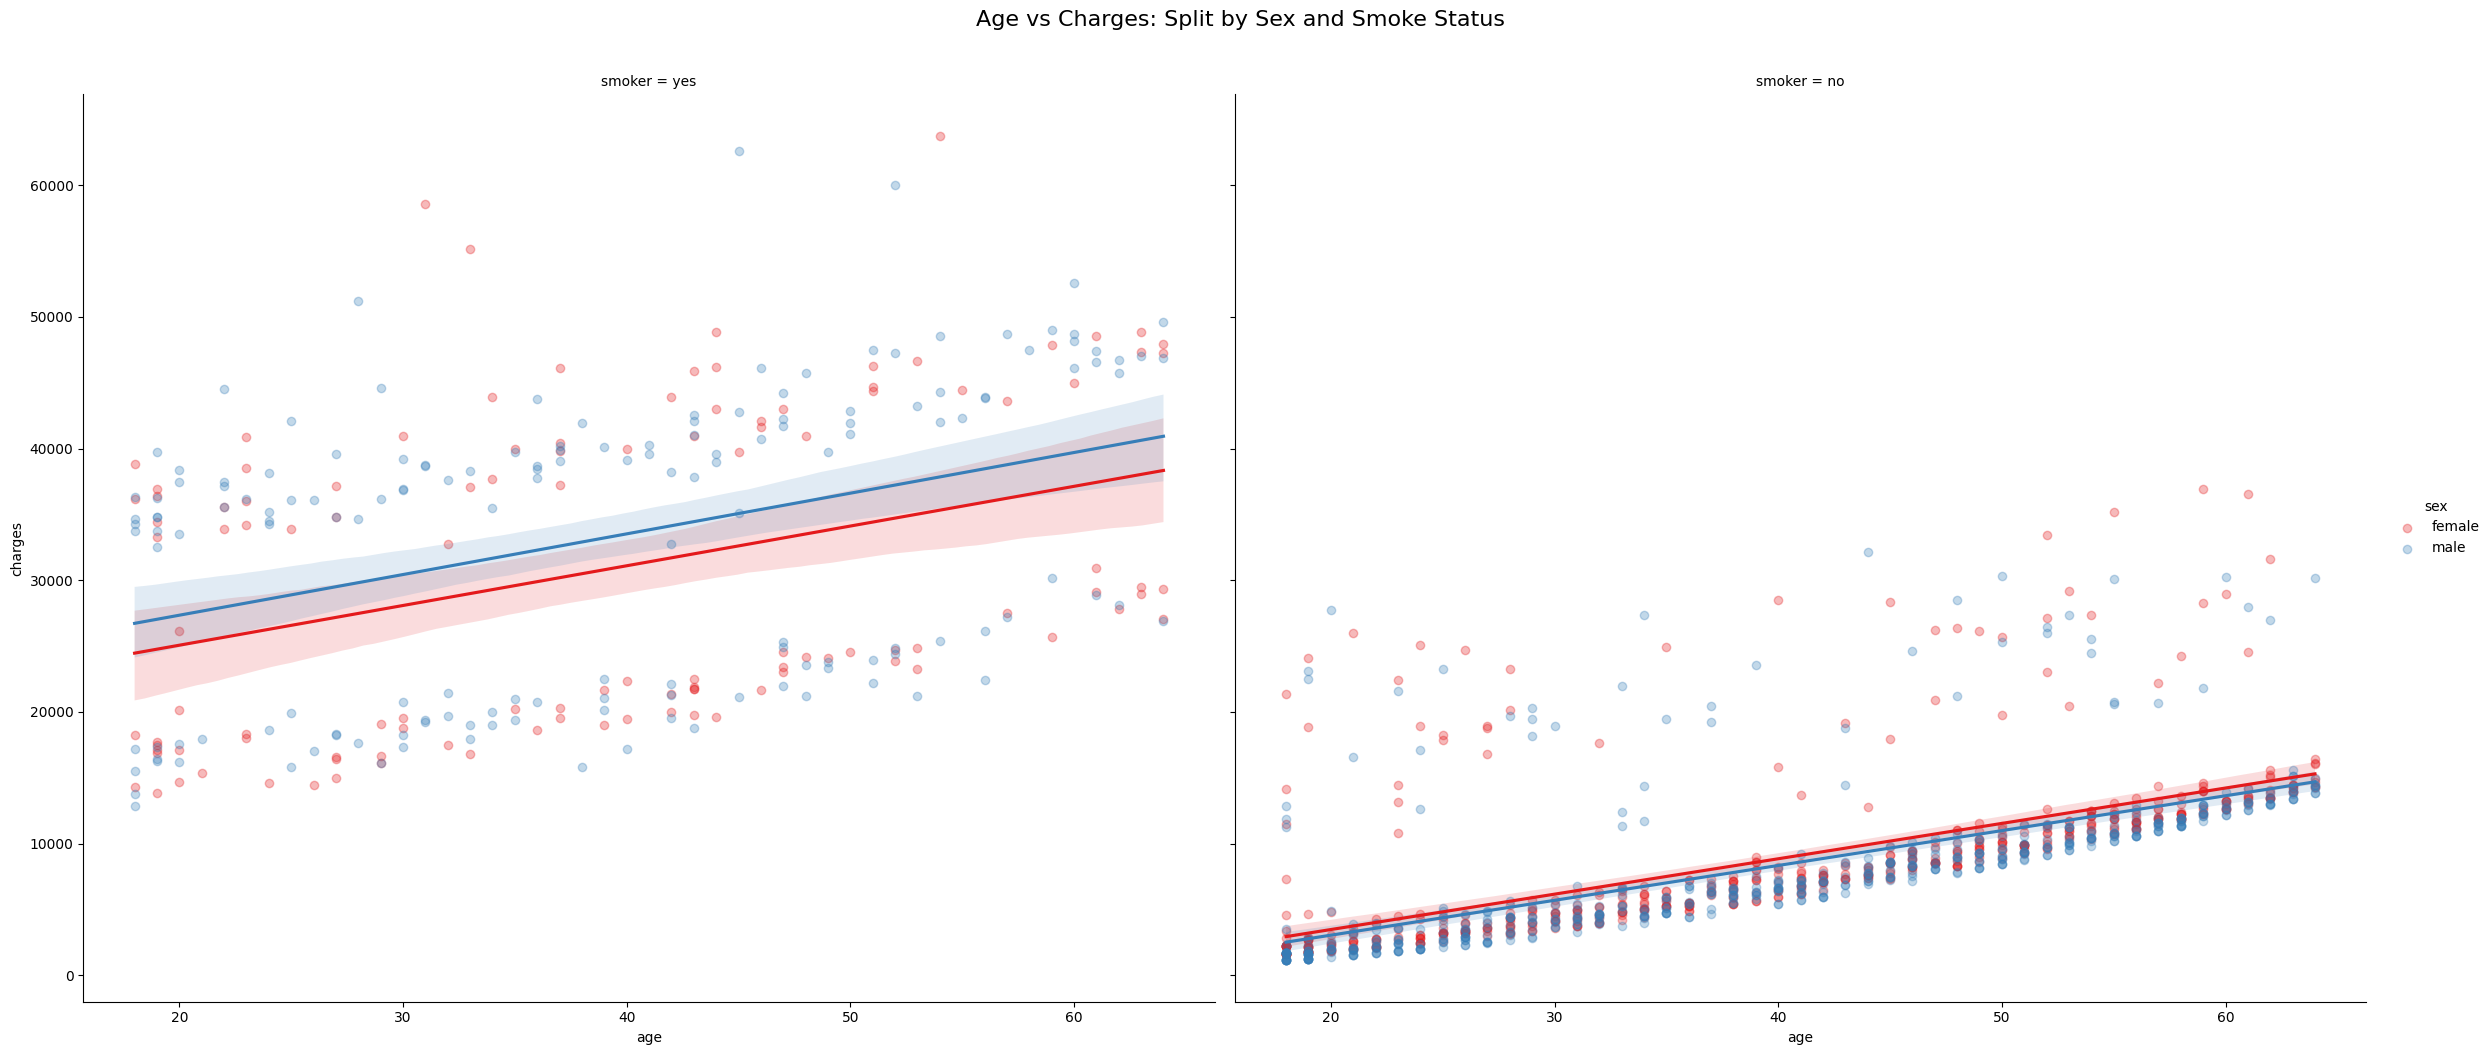

In [20]:
sns.lmplot(x="age", y="charges",hue="sex",col="smoker",
           col_wrap=2, height=10,aspect=1.2, palette="Set1", data=df,
           scatter_kws={"alpha":0.3})

plt.suptitle("Age vs Charges: Split by Sex and Smoke Status", y=1.05, fontsize=16)
plt.show()

Age vs Charges: Split by Sex and Smoke Status

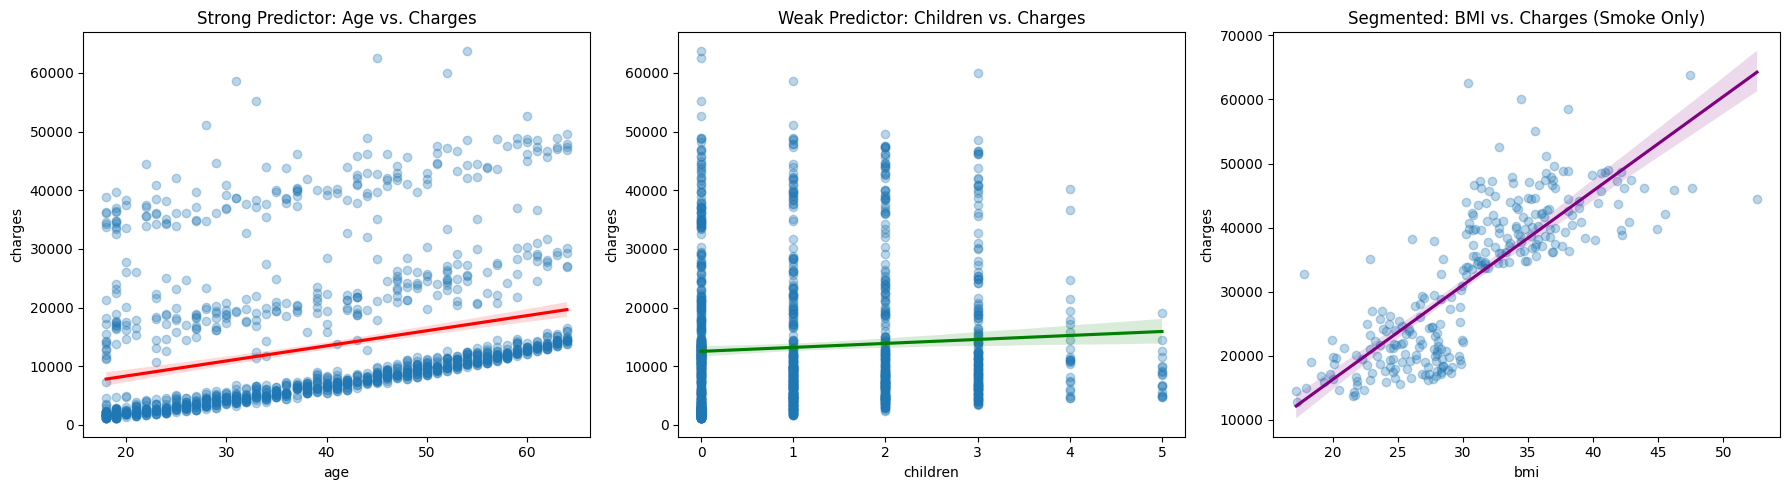

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(ax=axes[0], x='age', y='charges' ,data =df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[0].set_title("Strong Predictor: Age vs. Charges")

sns.regplot(ax=axes[1], x='children', y='charges' ,data =df, scatter_kws={'alpha':0.3}, line_kws={'color':'green'})
axes[1].set_title("Weak Predictor: Children vs. Charges")

sns.regplot(ax=axes[2], x='bmi', y='charges' ,data =df[df["smoker"]== "yes"], scatter_kws={'alpha':0.3}, line_kws={'color':'purple'})
axes[2].set_title("Segmented: BMI vs. Charges (Smoke Only)")

plt.tight_layout()
plt.show()